Number of keypoints in Image 1: 200
Number of keypoints in Image 2: 200
Number of matches: 49
Best match distance: 60.0
Worst match distance: 87.0


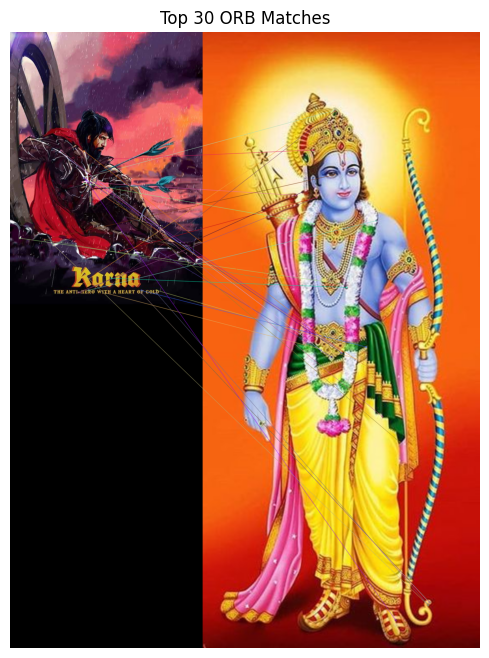

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read Image 1
image1 = cv2.imread('/content/drive/MyDrive/Colab Notebooks/Images/karna.jpg')

# Read Image 2
image2 = cv2.imread('/content/drive/MyDrive/Colab Notebooks/Images/Ram.jpg')

# Convert both to grayscale
gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# Create ORB
orb = cv2.ORB_create(
    nfeatures=200
)

# Detect keypoints and descriptors
keypoints1, descriptors1 = orb.detectAndCompute(
    gray1,
    None
)

keypoints2, descriptors2 = orb.detectAndCompute(
    gray2,
    None
)
# Create BFMatcher
bf = cv2.BFMatcher(
    cv2.NORM_HAMMING,
    crossCheck=True
)

# Match descriptors
matches = bf.match(descriptors1, descriptors2)

# Sort matches
matches = sorted(
    matches,
    key=lambda x: x.distance
)
# Draw best 30 matches
matched = cv2.drawMatches(
    image1,
    keypoints1,
    image2,
    keypoints2,
    matches[:30],
    None,
    flags=2
)

# Print:
# Number of keypoints in Image 1
print("Number of keypoints in Image 1:", len(keypoints1))

# Number of keypoints in Image 2
print("Number of keypoints in Image 2:", len(keypoints2))

# Number of matches
print("Number of matches:", len(matches))

# Best match distance
print("Best match distance:", matches[0].distance)

# Worst match distance
print("Worst match distance:", matches[-1].distance)


plt.figure(figsize=(15,8))

plt.imshow(
    cv2.cvtColor(
        matched,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title("Top 30 ORB Matches")

plt.show()